Run a simulation and sample genomes from the transmission network.

Sample at say 1%, 5%, and 10% of the transmissions (to begin with) and reconstruct the phylogeny.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import covasim as cv
from Bio import SeqIO

from covasim.transmission_tree import TransmissionTree
from covasim.metrics import Metrics
from covasim.inference import Inference

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM


In [2]:
REF_FASTA     = 'sars-2-data/NC_045512_Hu-1.fasta'
FITNESS_CSV   = '../../data/nt_fitness.csv'
ARTIC_PRIMERS = 'sars-2-data/ARTIC_V4-1.bed'

ay4_fasta   = 'sars-2-data/variants/AY.4_consensus.fasta'
ba2_fasta   = 'sars-2-data/variants/BA.2.9_consensus.fasta'
xbb15_fasta = 'sars-2-data/variants/XBB.1.5.18_consensus.fasta'


In [3]:
ay4 = cv.variant(
    variant        = {},
    label          = 'AY.4',
    days           = 30,
    n_imports      = 60,
    founding_fasta = ay4_fasta,
)
ba2 = cv.variant(
    variant        = {},
    label          = 'BA.2',
    days           = 70,
    n_imports      = 60,
    founding_fasta = ba2_fasta,
)
xbb15 = cv.variant(
    variant        = {},
    label          = 'XBB.1.5',
    days           = 110,
    n_imports      = 60,
    founding_fasta = xbb15_fasta,
)

sample_days = list(range(90, 181, 10))
# Routine clinical: 50 symptomatic agents per day, every 10 days.
cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 50,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

In [4]:
sim = cv.Sim(dict(
    pop_size     = 5_000,
    pop_infected = 1,
        start_day    = '2022-09-01',
        end_day      = '2023-03-31',
    evo_pars = dict(
        enable            = True,
        reference         = REF_FASTA,
        mol_clock_rate    = 1e-6,   # ~1 substitution/genome/month at 30 000 nt
        sub_model         = 'JC', # decides which mutations happen
        fitness_model = "bloom_nt", # controls transmission rate
        fitness_data_path = FITNESS_CSV,
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [cs_routine],
    verbose   = 0,
))
sim.run()

cs_routine = sim.get_analyzer('CS_routine')

In [5]:
variant_names = list(sim['variant_map'].values())
n_inf         = sim.results['variant']['n_infectious_by_variant'].values
total         = n_inf.sum(axis=0)
total[total == 0] = 1
props = {v: n_inf[i] / total for i, v in enumerate(variant_names)}

In [6]:
sim.summarize() 

Simulation summary:
       38,015 cumulative infections
       33,015 cumulative reinfections
       37,202 cumulative infectious
       17,363 cumulative symptomatic cases
          693 cumulative severe cases
          232 cumulative critical cases
       35,476 cumulative recoveries
           91 cumulative deaths
            0 cumulative tests
            0 cumulative diagnoses
            0 cumulative known deaths
            0 cumulative quarantined people
            0 cumulative isolated people
            0 cumulative vaccine doses
            0 cumulative vaccinated people



In [7]:
print(f"pop_size (actual agents):     {sim['pop_size']}")
print(f"pop_scale:                    {sim['pop_scale']}")
print(f"scaled_pop_size:              {sim.scaled_pop_size}")
print(f"rescale:                      {sim['rescale']}")

# current scale factor at end of sim
print(f"final scale factor:           {sim.rescale_vec[-1]:.1f}")

pop_size (actual agents):     5000
pop_scale:                    1
scaled_pop_size:              5000
rescale:                      True
final scale factor:           1.0


In [8]:
def variant_counts(samples):
    '''Count how many sampled agents carry each variant label.'''
    counts = {}
    for s in samples:
        counts[s.variant_label] = counts.get(s.variant_label, 0) + 1
    return counts


print('Routine clinical sequencing (n=50/day, pool=symptomatic, immediate release):')
header = f'  {"Release":>7}  {"Date":>12}  {"N seq":>6}  ' + \
         '  '.join(f'{v:>10}' for v in variant_names)
print(header)
print('  ' + '-' * (len(header) - 2))

for day in sorted(cs_routine.samples):
    batch = cs_routine.samples[day]
    if not batch:
        print(f'  {day:>7}  {sim.date(day):>12}  {"—":>6}')
        continue
    counts = variant_counts(batch)
    n = len(batch)
    cols = '  '.join(
        f'{counts.get(v, 0) / n:>9.1%}' for v in variant_names
    )
    print(f'  {day:>7}  {sim.date(day):>12}  {n:>6}  {cols}')

Routine clinical sequencing (n=50/day, pool=symptomatic, immediate release):
  Release          Date   N seq        wild        AY.4        BA.2     XBB.1.5
  -----------------------------------------------------------------------------
       90    2022-11-30      50       0.0%      36.0%      64.0%       0.0%
      100    2022-12-10      50       0.0%       6.0%      94.0%       0.0%
      110    2022-12-20      50       0.0%       0.0%     100.0%       0.0%
      120    2022-12-30      50       0.0%       0.0%      92.0%       8.0%
      130    2023-01-09      50       0.0%       0.0%      76.0%      24.0%
      140    2023-01-19      50       0.0%       0.0%      50.0%      50.0%
      150    2023-01-29      50       0.0%       0.0%      30.0%      70.0%
      160    2023-02-08      50       0.0%       0.0%      12.0%      88.0%
      170    2023-02-18      50       0.0%       0.0%       4.0%      96.0%
      180    2023-02-28      50       0.0%       0.0%       2.0%      98.0%


In [9]:
log    = sim.people.infection_log
n_muts = [e['n_mutations'] for e in log if 'n_mutations' in e]

print(f'Transmission events:    {len(log):,}')
print(f'Mean branch mutations:  {np.mean(n_muts):.3f}')
print(f'Max branch mutations:   {max(n_muts)}')

Transmission events:    38,015
Mean branch mutations:  0.219
Max branch mutations:   5


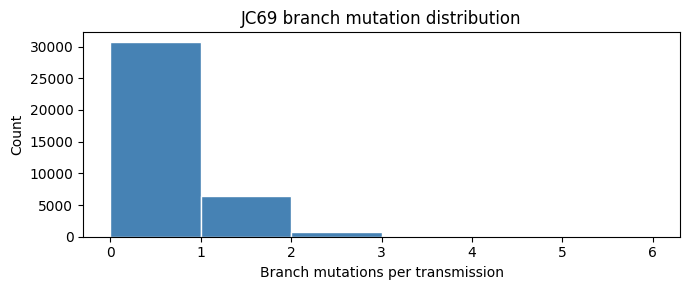

In [10]:
# Distribution of branch mutations across all transmission edges
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(n_muts, bins=range(max(n_muts) + 2), color='steelblue', edgecolor='white')
ax.set_xlabel('Branch mutations per transmission')
ax.set_ylabel('Count')
ax.set_title('JC69 branch mutation distribution')
plt.tight_layout()
plt.show()

In [11]:
# Reconstruct haplotypes for the first few agents and count divergence from reference
tracker = sim.sequence_tracker
ref_seq = cv.decode_sequence(tracker.reference)

sample_agents = [int(e['target']) for e in log[:5]]
for agent in sample_agents:
    hap   = tracker.reconstruct_haplotype(agent)
    ndiff = sum(a != b for a, b in zip(hap, ref_seq))
    print(f'  Agent {agent:6d}: {ndiff} mutation(s) vs reference')

  Agent   2764: 84 mutation(s) vs reference
  Agent   3828: 84 mutation(s) vs reference
  Agent   1952: 84 mutation(s) vs reference
  Agent   3751: 83 mutation(s) vs reference
  Agent   1116: 81 mutation(s) vs reference


In [12]:
focus_day = 180 # this has to be the sample day
cs_batch = cs_routine.samples.get(focus_day, [])

print(f'Day {focus_day} ({sim.date(focus_day)}) — clinical estimate vs true simulation proportions:')
print(f'  {"Variant":12s}  {"Clinical (n=50)":>16}  {"True (sim)":>12}  {"Diff":>8}')
print('  ' + '-' * 56)

for v in variant_names:
    clin_pct = 0.0
    if cs_batch:
        counts = variant_counts(cs_batch)
        clin_pct = counts.get(v, 0) / len(cs_batch)
    true_pct = props[v][focus_day]
    diff     = clin_pct - true_pct
    sign     = '+' if diff >= 0 else ''
    print(f'  {v:12s}  {clin_pct:>16.1%}  {true_pct:>12.1%}  {sign}{diff:>7.1%}')

Day 180 (2023-02-28) — clinical estimate vs true simulation proportions:
  Variant        Clinical (n=50)    True (sim)      Diff
  --------------------------------------------------------
  wild                      0.0%          0.0%  +   0.0%
  AY.4                      0.0%          2.1%    -2.1%
  BA.2                      2.0%          1.3%  +   0.7%
  XBB.1.5                  98.0%         96.6%  +   1.4%


In [13]:
fasta_str = cs_routine.to_fasta(focus_day)
fasta_out = f'./res/clinical_day{focus_day}_0.01.fasta'
with open(fasta_out, 'w') as fh:
    fh.write(fasta_str + '\n')
print(f'Saved clinical FASTA -> {fasta_out}')
print(f'  ({len(cs_batch)} sequences, {len(fasta_str)} characters)')
print('\nFirst two FASTA records:')
for line in fasta_str.split('\n')[:4]:
    print(' ', line[:100])

Saved clinical FASTA -> ./res/clinical_day180_0.01.fasta
  (50 sequences, 1497937 characters)

First two FASTA records:
  >agent_1768  day=180  date=2023-02-28  variant=XBB.1.5
  ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTC
  >agent_1566  day=180  date=2023-02-28  variant=XBB.1.5
  ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTC


In [ ]:


# full transmission tree
full_tt_tree = TransmissionTree(
    tt=sim.make_transtree(),
    ref_seq=list(str(SeqIO.read(REF_FASTA, "fasta").seq)),
)
full_tt_tree.build_tree() 
full_tt_tree.construct_newick()
full_tt_tree.save_newick("./full_tt.nwk")

metrics = Metrics()
n_mut = metrics.count_mutations("./full_tt.nwk")

print("n mut in full transmission tree:", n_mut)

Saved combined tree to ./full_tt.nwk
n mut in full transmission tree: 8331.0


In [ ]:

iqtree_inference = Inference(
    fasta_path=f'./res/clinical_day180_0.01.fasta',
    prefix="sample_0.01", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()

Running: /home/yutianc/miniforge3/envs/covasim/bin/iqtree -s ./res/clinical_day180_0.01.fasta -m JC -asr -redo -pre sample_0.01
IQ-TREE version 3.1.3 for Linux x86 64-bit built Jul 26 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    profchaos.scripps.edu (AVX512, FMA3, 754 GB RAM)
Command: /home/yutianc/miniforge3/envs/covasim/bin/iqtree -s ./res/clinical_day180_0.01.fasta -m JC -asr -redo -pre sample_0.01
Seed:    415337 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Fri Sep  4 14:14:00 2026
Kernel:  AVX+FMA - 1 threads (384 CPU cores detected)

HINT: Use -nt option to specify number of threads because your CPU has 384 cores!
HINT: -nt AUTO will automatically determine the best number of threads to use.

Reading alignment file ./res/clinical_day180_0.01.fasta ... Fasta format detected
Reading fasta file: 

In [16]:
total_mut, per_branch_mut = iqtree_inference.count_mutations()
print("n mut in the sampled transmission tree:", total_mut)

n mut in the sampled transmission tree: 107


In [17]:
# sample rate 5%

cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 250,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

sim = cv.Sim(dict(
    pop_size     = 5_000,
    pop_infected = 1,
        start_day    = '2022-09-01',
        end_day      = '2023-03-31',
    evo_pars = dict(
        enable            = True,
        reference         = REF_FASTA,
        mol_clock_rate    = 1e-6,   # ~1 substitution/genome/month at 30 000 nt
        sub_model         = 'JC', # decides which mutations happen
        fitness_model = "bloom_nt", # controls transmission rate
        fitness_data_path = FITNESS_CSV,
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [cs_routine],
    verbose   = 0,
))
sim.run()

cs_routine = sim.get_analyzer('CS_routine')

focus_day = 180 # this has to be the sample day
cs_batch = cs_routine.samples.get(focus_day, [])

print(f'Day {focus_day} ({sim.date(focus_day)}) — clinical estimate vs true simulation proportions:')
print(f'  {"Variant":12s}  {"Clinical (n=50)":>16}  {"True (sim)":>12}  {"Diff":>8}')
print('  ' + '-' * 56)

for v in variant_names:
    clin_pct = 0.0
    if cs_batch:
        counts = variant_counts(cs_batch)
        clin_pct = counts.get(v, 0) / len(cs_batch)
    true_pct = props[v][focus_day]
    diff     = clin_pct - true_pct
    sign     = '+' if diff >= 0 else ''
    print(f'  {v:12s}  {clin_pct:>16.1%}  {true_pct:>12.1%}  {sign}{diff:>7.1%}')

fasta_str = cs_routine.to_fasta(focus_day)
fasta_out = f'./res/clinical_day{focus_day}_0.05.fasta'
with open(fasta_out, 'w') as fh:
    fh.write(fasta_str + '\n')

iqtree_inference = Inference(
    fasta_path=f'./res/clinical_day180_0.05.fasta',
    prefix="sample_0.05", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()

total_mut, per_branch_mut = iqtree_inference.count_mutations()
print("n mut in the sampled transmission tree:", total_mut)

Day 180 (2023-02-28) — clinical estimate vs true simulation proportions:
  Variant        Clinical (n=50)    True (sim)      Diff
  --------------------------------------------------------
  wild                      0.0%          0.0%  +   0.0%
  AY.4                      0.0%          2.1%    -2.1%
  BA.2                      0.8%          1.3%    -0.5%
  XBB.1.5                  99.2%         96.6%  +   2.6%
Saved clinical FASTA -> ./res/clinical_day180_0.05.fasta
  (250 sequences, 7489689 characters)

First two FASTA records:
  >agent_3888  day=180  date=2023-02-28  variant=XBB.1.5
  ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTC
  >agent_1045  day=180  date=2023-02-28  variant=XBB.1.5
  ATTAAAGGTTTATACCTTCCCAGGTAACAAACCAACCAACTTTCGATCTCTTGTAGATCTGTTCTCTAAACGAACTTTAAAATCTGTGTGGCTGTCACTC
Running: /home/yutianc/miniforge3/envs/covasim/bin/iqtree -s ./res/clinical_day180_0.05.fasta -m JC -asr -redo -pre sample_0.05
IQ-TREE version 

In [18]:
# sample rate 10%
cs_routine = cv.ClinicalSequencer(
    days      = sample_days,
    n_samples = 500,
    pool      = 'symptomatic',
    label     = 'CS_routine',
    # sequencing_batch_size defaults to 1, causing immediate release
)

sim = cv.Sim(dict(
    pop_size     = 5_000,
    pop_infected = 1,
        start_day    = '2022-09-01',
        end_day      = '2023-03-31',
    evo_pars = dict(
        enable            = True,
        reference         = REF_FASTA,
        mol_clock_rate    = 1e-6,   # ~1 substitution/genome/month at 30 000 nt
        sub_model         = 'JC', # decides which mutations happen
        fitness_model = "bloom_nt", # controls transmission rate
        fitness_data_path = FITNESS_CSV,
    ),
    variants  = [ay4, ba2, xbb15],
    analyzers = [cs_routine],
    verbose   = 0,
))
sim.run()

cs_routine = sim.get_analyzer('CS_routine')

focus_day = 180 # this has to be the sample day
cs_batch = cs_routine.samples.get(focus_day, [])

print(f'Day {focus_day} ({sim.date(focus_day)}) — clinical estimate vs true simulation proportions:')
print(f'  {"Variant":12s}  {"Clinical (n=50)":>16}  {"True (sim)":>12}  {"Diff":>8}')
print('  ' + '-' * 56)

for v in variant_names:
    clin_pct = 0.0
    if cs_batch:
        counts = variant_counts(cs_batch)
        clin_pct = counts.get(v, 0) / len(cs_batch)
    true_pct = props[v][focus_day]
    diff     = clin_pct - true_pct
    sign     = '+' if diff >= 0 else ''
    print(f'  {v:12s}  {clin_pct:>16.1%}  {true_pct:>12.1%}  {sign}{diff:>7.1%}')

fasta_str = cs_routine.to_fasta(focus_day)
fasta_out = f'./res/clinical_day{focus_day}_0.1.fasta'
with open(fasta_out, 'w') as fh:
    fh.write(fasta_str + '\n')
print(f'Saved clinical FASTA -> {fasta_out}')
print(f'  ({len(cs_batch)} sequences, {len(fasta_str)} characters)')

iqtree_inference = Inference(
    fasta_path=f'./res/clinical_day180_0.1.fasta',
    prefix="sample_0.1", 
    model="JC",
)
iqtree_inference.run_iqtree_asr()

total_mut, per_branch_mut = iqtree_inference.count_mutations()
print("n mut in the sampled transmission tree:", total_mut)

/home/yutianc/covasim4wastewater/covasim/clinical.py:194: UserWarning: ClinicalSequencer day 90: requested 500 samples but only 390 agents are available in pool='symptomatic'. Returning all 390 agents.
  warnings.warn(


Day 180 (2023-02-28) — clinical estimate vs true simulation proportions:
  Variant        Clinical (n=50)    True (sim)      Diff
  --------------------------------------------------------
  wild                      0.0%          0.0%  +   0.0%
  AY.4                      0.0%          2.1%    -2.1%
  BA.2                      0.8%          1.3%    -0.5%
  XBB.1.5                  99.2%         96.6%  +   2.6%
Saved clinical FASTA -> ./res/clinical_day180_0.1.fasta
  (500 sequences, 14979377 characters)
Running: /home/yutianc/miniforge3/envs/covasim/bin/iqtree -s ./res/clinical_day180_0.1.fasta -m JC -asr -redo -pre sample_0.1
IQ-TREE version 3.1.3 for Linux x86 64-bit built Jul 26 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    profchaos.scripps.edu (AVX512, FMA3, 754 GB RAM)
Command: /home/yutianc/miniforge3/envs/covasim/

In [2]:
metrics = Metrics()

pd = metrics.tree_distance("./full_tt.nwk", "./sample_0.01.treefile", metric="faith_pd", alignment_length=29903)
print("rf distance: ", pd)

pd = metrics.tree_distance("./full_tt.nwk", "./sample_0.05.treefile", metric="faith_pd", alignment_length=29903)
print("rf distance: ", pd)

pd = metrics.tree_distance("./full_tt.nwk", "./sample_0.1.treefile", metric="faith_pd", alignment_length=29903)
print("rf distance: ", pd)

rf distance:  {'pd_tree1': 225.0, 'pd_tree2': 107.72474712870013, 'pd_difference': 117.27525287129987, 'n_shared_taxa': 47, 'alignment_length': 29903}
rf distance:  {'pd_tree1': 878.0, 'pd_tree2': 252.432439178499, 'pd_difference': 625.567560821501, 'n_shared_taxa': 232, 'alignment_length': 29903}
rf distance:  {'pd_tree1': 1489.0, 'pd_tree2': 391.41079118579694, 'pd_difference': 1097.5892088142032, 'n_shared_taxa': 452, 'alignment_length': 29903}
